Loaded example-star files from: /mnt/zfs/jupyter-p03/home/b6carter/Standard MS System
Solving model for Tc = 6.000e+06 K
  found: M=0.341 Msun, R=0.068 Rsun, L=1.387e+00 Lsun, Teff=20504 K
Solving model for Tc = 7.408e+06 K
  found: M=0.357 Msun, R=0.069 Rsun, L=3.307e+00 Lsun, Teff=29571 K
Solving model for Tc = 9.146e+06 K
  found: M=0.345 Msun, R=0.078 Rsun, L=5.017e+00 Lsun, Teff=30843 K
Solving model for Tc = 1.129e+07 K
  found: M=0.369 Msun, R=0.083 Rsun, L=1.083e+01 Lsun, Teff=36259 K
Solving model for Tc = 1.394e+07 K
  found: M=0.396 Msun, R=0.109 Rsun, L=1.315e+01 Lsun, Teff=33154 K
Solving model for Tc = 1.721e+07 K
  found: M=0.464 Msun, R=0.104 Rsun, L=5.692e+01 Lsun, Teff=49158 K
Solving model for Tc = 2.125e+07 K
  found: M=0.546 Msun, R=0.106 Rsun, L=8.838e+02 Lsun, Teff=96729 K
Solving model for Tc = 2.624e+07 K
  found: M=1.145 Msun, R=0.289 Rsun, L=1.068e+04 Lsun, Teff=109821 K
Solving model for Tc = 3.240e+07 K
  found: M=4.889 Msun, R=1.108 Rsun, L=2.267e+05 Lsun,

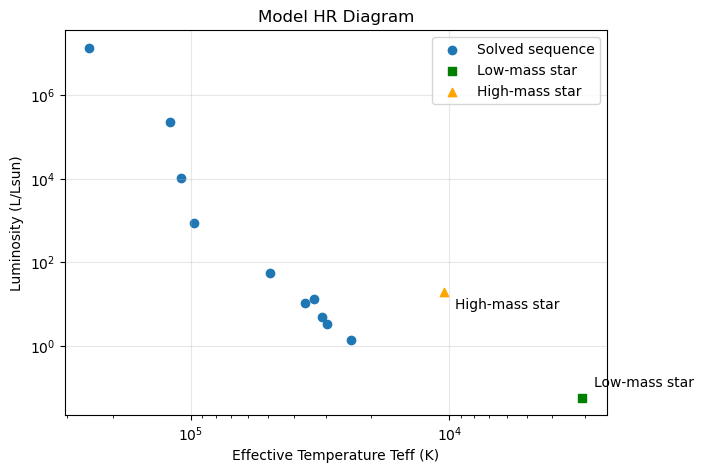

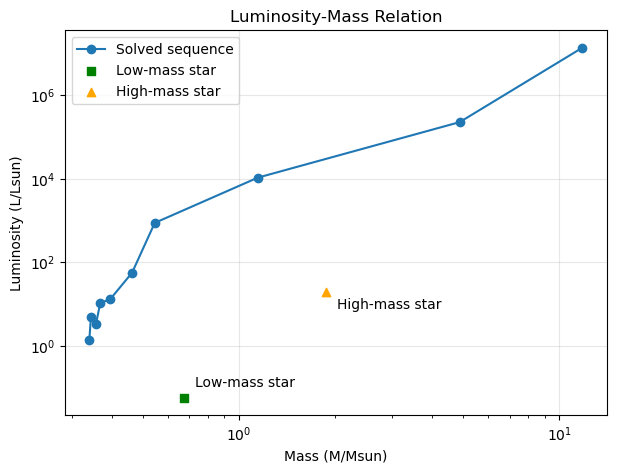

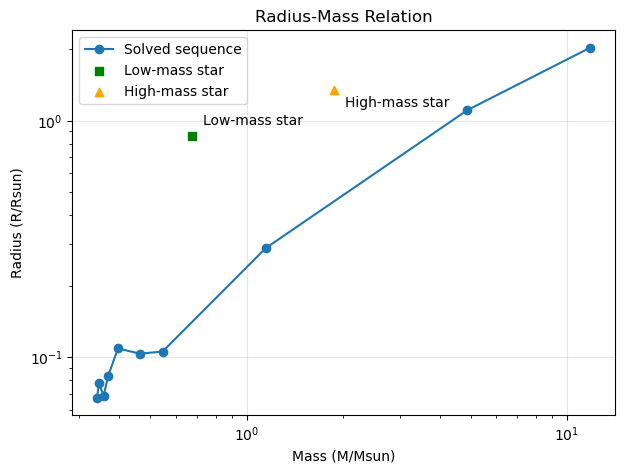


Low-mass star:
  M = 0.673 Msun
  R = 0.865 Rsun
  L = 5.877e-02 Lsun
  Teff = 3056 K


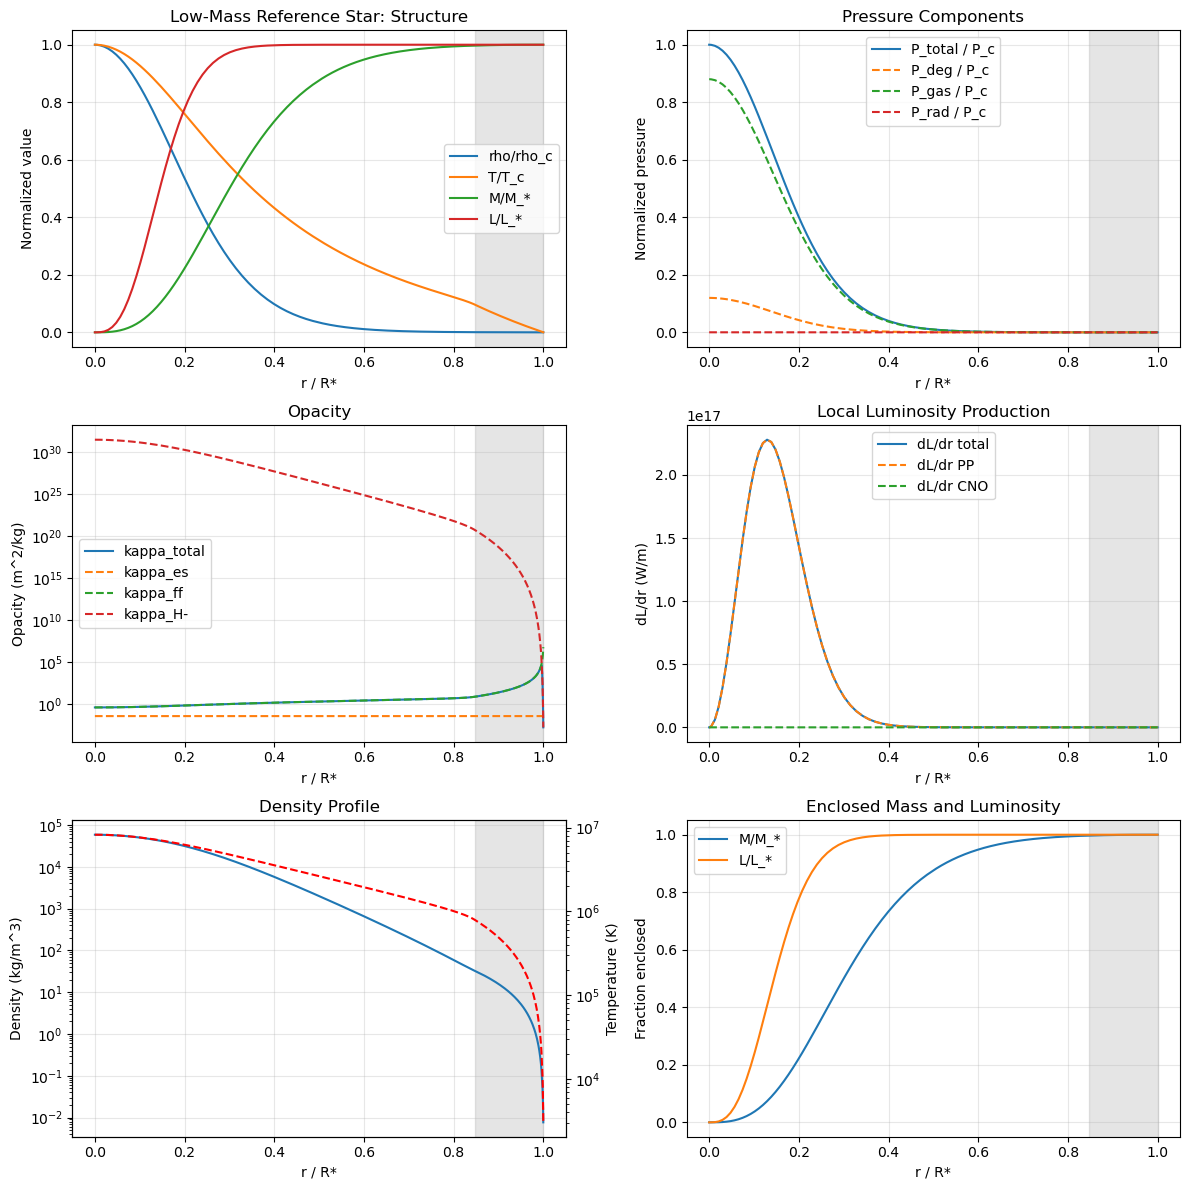


High-mass star:
  M = 1.867 Msun
  R = 1.343 Rsun
  L = 1.964e+01 Lsun
  Teff = 10486 K


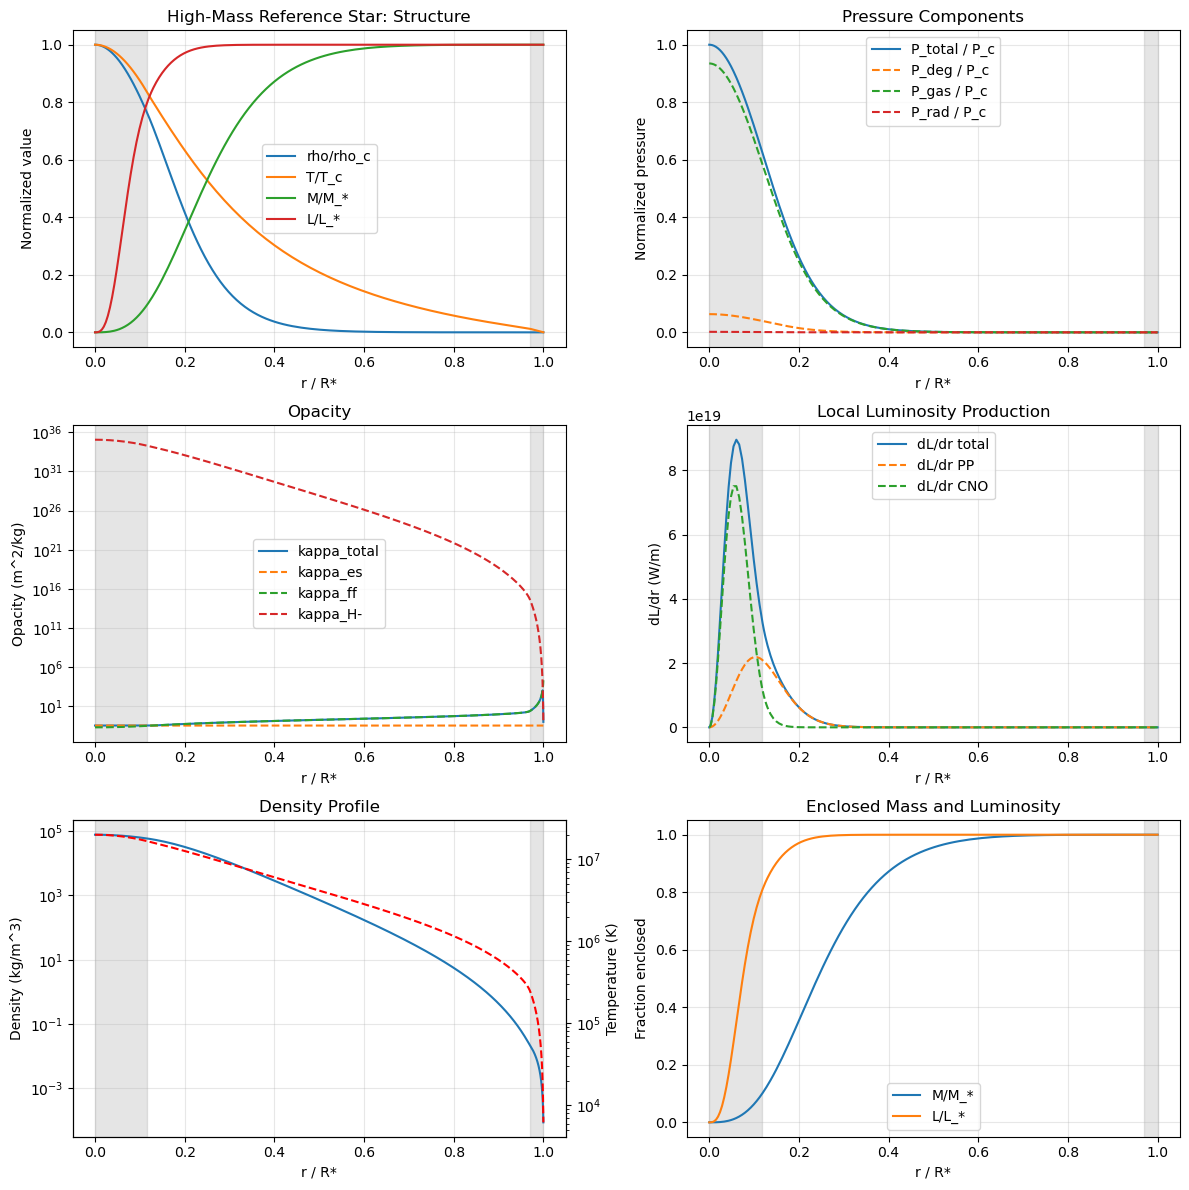

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt


# Simple main-sequence stellar structure solver
#
# The standard system of 5 equations:
#   d(rho)/dr, dT/dr, dM/dr, dL/dr, d(tau)/dr
#
# shooting method:
#   - choose central temperature Tc
#   - vary central density rho_c until the surface luminosity
#     condition L = 4*pi*sigma*R^2*T^4 is satisfied



# Folder that contains this notebook and the two text files.
# If the notebook is saved inside the "Standard MS System" folder, keep DATA_FOLDER = "."
# If you run the notebook from a different location, change DATA_FOLDER to that folder path.
DATA_FOLDER = "."
LOW_MASS_FILENAME = "lowmass_star.txt"
HIGH_MASS_FILENAME = "highmass_star.txt"

# Physical constants
G = 6.67430e-11
k_B = 1.380649e-23
hbar = 1.054571817e-34
m_e = 9.10938356e-31
m_p = 1.67262192369e-27
c = 2.99792458e8
sigma_sb = 5.670374419e-8
pi = np.pi
a_rad = 4.0 * sigma_sb / c

# Solar values for plotting
M_sun = 1.98847e30
R_sun = 6.957e8
L_sun = 3.828e26

# Composition
X = 0.70
Y = 0.28
Z = 0.02
X_CNO = 0.03 * X

# Mean molecular weight for fully ionized gas
mu = 1.0 / (2.0 * X + 0.75 * Y + 0.5 * Z)

# Adiabatic index used in convective gradient
gamma_ad = 5.0 / 3.0


# Helpful functions

def pressure_total(rho, T):
    """Total pressure = degeneracy + ideal gas + radiation."""
    # Non-relativistic electron degeneracy pressure
    P_deg = ((3.0 * pi**2)**(2.0 / 3.0) / 5.0) * (hbar**2 / m_e) * (rho / m_p)**(5.0 / 3.0)

    # Ideal gas pressure
    P_gas = rho * k_B * T / (mu * m_p)

    # Radiation pressure
    P_rad = (1.0 / 3.0) * a_rad * T**4

    return P_deg + P_gas + P_rad


def pressure_parts(rho, T):
    """Return pressure pieces separately for plotting."""
    P_deg = ((3.0 * pi**2)**(2.0 / 3.0) / 5.0) * (hbar**2 / m_e) * (rho / m_p)**(5.0 / 3.0)
    P_gas = rho * k_B * T / (mu * m_p)
    P_rad = (1.0 / 3.0) * a_rad * T**4
    return P_deg, P_gas, P_rad


def dP_drho(rho, T):
    """Partial derivative dP/drho at fixed T."""
    term_deg = ((3.0 * pi**2)**(2.0 / 3.0) / 3.0) * (hbar**2 / (m_e * m_p)) * (rho / m_p)**(2.0 / 3.0)
    term_gas = k_B * T / (mu * m_p)
    return term_deg + term_gas


def dP_dT(rho, T):
    """Partial derivative dP/dT at fixed rho."""
    term_gas = rho * k_B / (mu * m_p)
    term_rad = (4.0 / 3.0) * a_rad * T**3
    return term_gas + term_rad


def epsilon_pp(rho, T):
    """PP-chain energy generation in W/kg."""
    rho5 = rho / 1.0e5
    T6 = T / 1.0e6
    if T6 <= 0:
        return 0.0
    return 1.07e-7 * rho5 * X**2 * T6**4


def epsilon_cno(rho, T):
    """CNO-cycle energy generation in W/kg."""
    rho5 = rho / 1.0e5
    T6 = T / 1.0e6
    if T6 <= 0:
        return 0.0
    return 8.24e-26 * rho5 * X * X_CNO * T6**19.9


def epsilon_total(rho, T):                          # <-- Will need to modify to add a DM term later
    """Total specific energy generation."""
    return epsilon_pp(rho, T) + epsilon_cno(rho, T)


def opacity_parts(rho, T):
    """Return kappa_es, kappa_ff, kappa_Hminus separately."""
    rho3 = max(rho / 1.0e3, 1.0e-30)
    T = max(T, 1.0)

    k_es = 0.02 * (1.0 + X)
    k_ff = 1.0e24 * (Z + 0.0001) * rho3**0.7 * T**(-3.5)
    k_hm = 2.5e-32 * (Z / 0.02) * rho3**0.5 * T**9
    return k_es, k_ff, k_hm


def opacity_total(rho, T):
    """Combined opacity formula."""
    k_es, k_ff, k_hm = opacity_parts(rho, T)
    k_highT = max(k_es, k_ff)
    # Smooth combination that switches to H- near the surface
    return 1.0 / (1.0 / max(k_hm, 1.0e-40) + 1.0 / max(k_highT, 1.0e-40))



def effective_temperature_from_surface(surface):
    """Compute Teff from luminosity and radius using Stefan-Boltzmann."""
    radius = max(surface['r'], 1.0e-30)
    luminosity = max(surface['L'], 0.0)
    return (luminosity / (4.0 * pi * sigma_sb * radius**2))**0.25


def convective_from_dlogP_dlogT(dlogP_dlogT):
    """Approximate convective zones from the tabulated stability ratio."""
    threshold = gamma_ad / (gamma_ad - 1.0)
    return dlogP_dlogT <= threshold + 1.0e-8


def load_reference_star_file(file_path, label):
    """Load one example-star text file and convert cgs columns to SI units."""
    raw = np.loadtxt(file_path, comments='#')

    # Convert the columns used by the plots from cgs to SI.
    r = raw[:, 1] * 1.0e-2
    rho = raw[:, 2] * 1.0e3
    T = raw[:, 3]
    M_r = raw[:, 4] * 1.0e-3
    L_r = raw[:, 5] * 1.0e-7
    dLdr = raw[:, 6] * 1.0e-5
    dLppdr = raw[:, 7] * 1.0e-5
    dLcnodr = raw[:, 8] * 1.0e-5
    dlogP_dlogT = raw[:, 9]

    kappa = raw[:, 15] * 0.1
    k_hm = raw[:, 16] * 0.1
    k_ff = raw[:, 17] * 0.1
    k_es = raw[:, 18] * 0.1

    P = raw[:, 19] * 0.1
    P_deg = raw[:, 20] * 0.1
    P_gas = raw[:, 21] * 0.1
    P_rad = raw[:, 22] * 0.1

    shell_factor = 4.0 * pi * np.maximum(r, 1.0)**2 * np.maximum(rho, 1.0e-30)
    eps_pp = dLppdr / shell_factor
    eps_cno = dLcnodr / shell_factor

    model = {
        'label': label,
        'r': r,
        'rho': rho,
        'T': T,
        'M': M_r,
        'L': L_r,
        'P': P,
        'P_deg': P_deg,
        'P_gas': P_gas,
        'P_rad': P_rad,
        'kappa': kappa,
        'k_es': k_es,
        'k_ff': k_ff,
        'k_hm': k_hm,
        'dLdr': dLdr,
        'eps_pp': eps_pp,
        'eps_cno': eps_cno,
        'convective': convective_from_dlogP_dlogT(dlogP_dlogT),
        'surface': {
            'r': r[-1],
            'rho': rho[-1],
            'T': T[-1],
            'M': M_r[-1],
            'L': L_r[-1],
        },
    }
    model['surface']['Teff'] = effective_temperature_from_surface(model['surface'])
    return model


def load_example_stars_once(data_folder):
    """Load the low-mass and high-mass example files."""
    low_path = os.path.join(data_folder, LOW_MASS_FILENAME)
    high_path = os.path.join(data_folder, HIGH_MASS_FILENAME)

    if not os.path.exists(low_path):
        raise FileNotFoundError(f'Could not find {low_path}')
    if not os.path.exists(high_path):
        raise FileNotFoundError(f'Could not find {high_path}')

    example_stars = {
        'low': load_reference_star_file(low_path, 'Low-Mass Reference Star'),
        'high': load_reference_star_file(high_path, 'High-Mass Reference Star'),
    }
    return example_stars

# ODE system
# state = [rho, T, M, L, tau]

def stellar_derivatives(r, state):
    rho, T, M, L, tau = state

    # Prevent non-physical negative values during integration
    rho = max(rho, 1.0e-12)
    T = max(T, 1.0)
    M = max(M, 1.0e-30)
    r = max(r, 1.0)

    P = pressure_total(rho, T)
    kappa = opacity_total(rho, T)
    eps = epsilon_total(rho, T)

    # Radiative temperature gradient
    dTdr_rad = -(3.0 * kappa * rho * L) / (16.0 * pi * a_rad * c * T**3 * r**2)

    # Convective temperature gradient
    dTdr_conv = -((1.0 - 1.0 / gamma_ad) * T / P) * (G * M * rho / r**2)

    # Use the shallower magnitude gradient (the project says min of the two positive forms)
    if abs(dTdr_rad) < abs(dTdr_conv):
        dTdr = dTdr_rad
    else:
        dTdr = dTdr_conv

    # Hydrostatic equilibrium recast as d(rho)/dr
    dp_rho = dP_drho(rho, T)
    dp_T = dP_dT(rho, T)
    drhodr = -(G * M * rho / r**2 + dp_T * dTdr) / dp_rho

    # Mass, luminosity, optical depth equations
    dMdr = 4.0 * pi * r**2 * rho
    dLdr = 4.0 * pi * r**2 * rho * eps
    dtaudr = kappa * rho

    return np.array([drhodr, dTdr, dMdr, dLdr, dtaudr], dtype=float)


# Numerical helpers

def rk4_step(r, y, h):
    """One RK4 step."""
    k1 = stellar_derivatives(r, y)
    k2 = stellar_derivatives(r + 0.5 * h, y + 0.5 * h * k1)
    k3 = stellar_derivatives(r + 0.5 * h, y + 0.5 * h * k2)
    k4 = stellar_derivatives(r + h, y + h * k3)
    return y + (h / 6.0) * (k1 + 2.0 * k2 + 2.0 * k3 + k4)


def interpolate_surface_from_tau(history):
    """
    Find the photosphere by using tau(infinity) - tau(R*) = 2/3.
    Since we stop at a large finite radius, tau(infinity) is approximated
    by the last tau value in the integration.
    """
    tau_end = history['tau'][-1]
    target_tau = tau_end - 2.0 / 3.0

    # If the integration did not reach enough optical depth range,
    # just use the last point.
    if target_tau <= history['tau'][0]:
        i = len(history['tau']) - 2
    else:
        i = None
        for j in range(len(history['tau']) - 1):
            if history['tau'][j] <= target_tau <= history['tau'][j + 1]:
                i = j
                break
        if i is None:
            i = len(history['tau']) - 2

    tau1 = history['tau'][i]
    tau2 = history['tau'][i + 1]

    # Linear interpolation fraction
    if tau2 != tau1:
        f = (target_tau - tau1) / (tau2 - tau1)
    else:
        f = 0.0

    surface = {}
    for key in ['r', 'rho', 'T', 'M', 'L', 'tau']:
        v1 = history[key][i]
        v2 = history[key][i + 1]
        surface[key] = v1 + f * (v2 - v1)

    surface['index'] = i
    surface['frac'] = f
    return surface


def choose_step_size(r):
    """
    Very simple variable step size.
    Small near the center, slowly increasing outward.
    """
    return max(1.0e4, 0.01 * r)


# Solve one trial star for fixed rho_c and T_c

def integrate_star(rho_c, T_c, max_steps=50000):
    """
    Integrate outward from a small starting radius r0.
    """
    r0 = 1.0e3

    # Initial values
    eps_c = epsilon_total(rho_c, T_c)
    M0 = (4.0 / 3.0) * pi * r0**3 * rho_c
    L0 = (4.0 / 3.0) * pi * r0**3 * rho_c * eps_c
    y = np.array([rho_c, T_c, M0, L0, 0.0], dtype=float)

    # Lists for the full profile storage
    r_list = [r0]
    rho_list = [y[0]]
    T_list = [y[1]]
    M_list = [y[2]]
    L_list = [y[3]]
    tau_list = [y[4]]

    # Move outward one more radial step
    converged_outer = False

    r = r0
    for _ in range(max_steps):
        h = choose_step_size(r)
        y_new = rk4_step(r, y, h)

        # Stop if state becomes non-physical
        if y_new[0] <= 0 or y_new[1] <= 0 or np.any(np.isnan(y_new)) or np.any(np.isinf(y_new)):
            break

        r = r + h
        y = y_new

        r_list.append(r)
        rho_list.append(y[0])
        T_list.append(y[1])
        M_list.append(y[2])
        L_list.append(y[3])
        tau_list.append(y[4])

        # Estimate whether the outer boundary has been reached
        # Surface proxy: delta_tau ~ kappa rho^2 / |drho/dr|
        derivs = stellar_derivatives(r, y)
        drhodr = derivs[0]
        rho = max(y[0], 1.0e-30)
        T = max(y[1], 1.0)
        kappa = opacity_total(rho, T)

        if abs(drhodr) > 1.0e-40:
            delta_tau = kappa * rho**2 / abs(drhodr)
        else:
            delta_tau = 1.0e99

        # Practical stopping conditions
        if delta_tau < 1.0e-3 and T < 2.0e4:
            converged_outer = True
            break

        # Safety caps so trial solutions do not run forever
        if y[2] > 1000.0 * M_sun:
            break
        if r > 200.0 * R_sun:
            break

        # Put solution into 'history' dictionary
    history = {
        'r': np.array(r_list),
        'rho': np.array(rho_list),
        'T': np.array(T_list),
        'M': np.array(M_list),
        'L': np.array(L_list),
        'tau': np.array(tau_list),
        'outer_ok': converged_outer,
    }

    # If we have too few points --> fail
    if len(history['r']) < 3:
        return None

    surface = interpolate_surface_from_tau(history)

    # Add some useful derived quantities to the profile (for analysis and plotting)
    P_tot = []
    P_deg_list = []
    P_gas_list = []
    P_rad_list = []
    kappa_list = []
    k_es_list = []
    k_ff_list = []
    k_hm_list = []
    eps_pp_list = []
    eps_cno_list = []
    dLdr_list = []
    convective_flag = []

    for i in range(len(history['r'])):
        rr = history['r'][i]
        rho = history['rho'][i]
        T = history['T'][i]
        M = history['M'][i]
        L = history['L'][i]

        P = pressure_total(rho, T)
        P_deg, P_gas, P_rad = pressure_parts(rho, T)
        k_es, k_ff, k_hm = opacity_parts(rho, T)
        kappa = opacity_total(rho, T)
        eps_pp_val = epsilon_pp(rho, T)
        eps_cno_val = epsilon_cno(rho, T)
        dLdr = 4.0 * pi * rr**2 * rho * (eps_pp_val + eps_cno_val)

        dTdr_rad = -(3.0 * kappa * rho * L) / (16.0 * pi * a_rad * c * T**3 * rr**2)
        dTdr_conv = -((1.0 - 1.0 / gamma_ad) * T / P) * (G * M * rho / rr**2)
        is_convective = abs(dTdr_conv) <= abs(dTdr_rad)

        P_tot.append(P)
        P_deg_list.append(P_deg)
        P_gas_list.append(P_gas)
        P_rad_list.append(P_rad)
        kappa_list.append(kappa)
        k_es_list.append(k_es)
        k_ff_list.append(k_ff)
        k_hm_list.append(k_hm)
        eps_pp_list.append(eps_pp_val)
        eps_cno_list.append(eps_cno_val)
        dLdr_list.append(dLdr)
        convective_flag.append(is_convective)

    history['P'] = np.array(P_tot)
    history['P_deg'] = np.array(P_deg_list)
    history['P_gas'] = np.array(P_gas_list)
    history['P_rad'] = np.array(P_rad_list)
    history['kappa'] = np.array(kappa_list)
    history['k_es'] = np.array(k_es_list)
    history['k_ff'] = np.array(k_ff_list)
    history['k_hm'] = np.array(k_hm_list)
    history['eps_pp'] = np.array(eps_pp_list)
    history['eps_cno'] = np.array(eps_cno_list)
    history['dLdr'] = np.array(dLdr_list)
    history['convective'] = np.array(convective_flag, dtype=bool)
    history['surface'] = surface

    return history


# ----- V2 changes start here ------


# Surface boundary-condition mismatch function for shooting

def luminosity_surface_error(rho_c, T_c):
    """
    Return the mismatch function used in the shooting method.
    Root of this function corresponds to a star satisfying
    L(R*) = 4*pi*sigma*R*^2*T*^4
    """
    result = integrate_star(rho_c, T_c)
    if result is None:
        return None, None

    R_star = result['surface']['r']
    T_star = result['surface']['T']
    L_star = result['surface']['L']

    L_photo = 4.0 * pi * sigma_sb * R_star**2 * T_star**4

    # Normalized error
    denom = np.sqrt(max(L_star * L_photo, 1.0e-60))
    error = (L_star - L_photo) / denom

    return error, result


# Find rho_c for one chosen T_c using scan + bisection

def solve_star_for_Tc(T_c, rho_min=3.0e2, rho_max=1.0e7, scan_points=24, tol=1.0e-3, max_iter=40):
    """
    Step 1: scan for a sign change in the surface error.
    Step 2: use bisection on the bracket.
    """
    rho_values = np.logspace(np.log10(rho_min), np.log10(rho_max), scan_points)
    errors = []

    for rho_c in rho_values:
        err, _ = luminosity_surface_error(rho_c, T_c)
        errors.append(err)

    # Find a sign change bracket (finding the root)
    left = None
    right = None
    for i in range(len(rho_values) - 1):
        e1 = errors[i]
        e2 = errors[i + 1]
        if e1 is None or e2 is None:
            continue
        if e1 == 0:
            left = rho_values[i]
            right = rho_values[i]
            break
        if e1 * e2 < 0:
            left = rho_values[i]
            right = rho_values[i + 1]
            break

    if left is None:
        return None

    # If scan found an exact root, just return it
    if left == right:
        _, result = luminosity_surface_error(left, T_c)
        return result

    # Bisection loop (in case there is no exact root -> find a good enough result within a certain tolerance)
    best_result = None
    for _ in range(max_iter):
        mid = 0.5 * (left + right)
        e_left, _ = luminosity_surface_error(left, T_c)
        e_mid, result_mid = luminosity_surface_error(mid, T_c)
        best_result = result_mid

        if e_left is None or e_mid is None:
            return None

        if abs(e_mid) < tol:
            return result_mid

        if e_left * e_mid < 0:
            right = mid
        else:
            left = mid

        if abs(right - left) / mid < 1.0e-4:
            return result_mid

    return best_result


# Build a simple standard main sequence by varying T_c (returns mass, radius, luminosity, and surface temp)

def build_main_sequence(Tc_values):
    models = []
    for Tc in Tc_values:
        print(f"Solving model for Tc = {Tc:.3e} K")
        model = solve_star_for_Tc(Tc)
        if model is not None:
            models.append(model)
            s = model['surface']
            print(
                "  found: "
                f"M={s['M']/M_sun:.3f} Msun, "
                f"R={s['r']/R_sun:.3f} Rsun, "
                f"L={s['L']/L_sun:.3e} Lsun, "
                f"Teff={s['T']:.0f} K"
            )
        else:
            print("  no solution found")
    return models


# ----- V3 changes start here (additonal functions added above, too) ------


# Plotting helpers

def annotate_example_points(ax, x_low, y_low, x_high, y_high):
    """Add separate labels for the low-mass and high-mass stars."""
    ax.annotate('Low-mass star', xy=(x_low, y_low), xytext=(8, 8),
                textcoords='offset points')
    ax.annotate('High-mass star', xy=(x_high, y_high), xytext=(8, -12),
                textcoords='offset points')


def plot_main_sequence(models, example_stars=None):
    masses = np.array([m['surface']['M'] / M_sun for m in models])
    radii = np.array([m['surface']['r'] / R_sun for m in models])
    luminosities = np.array([m['surface']['L'] / L_sun for m in models])
    teff = np.array([effective_temperature_from_surface(m['surface']) for m in models])

    # HR diagram
    plt.figure(figsize=(7, 5))
    plt.scatter(teff, luminosities, label='Solved sequence')

    if example_stars is not None:
        low_teff = example_stars['low']['surface']['Teff']
        high_teff = example_stars['high']['surface']['Teff']
        low_lum = example_stars['low']['surface']['L'] / L_sun
        high_lum = example_stars['high']['surface']['L'] / L_sun
        plt.scatter([low_teff], [low_lum], marker='s', color = 'green', label='Low-mass star')
        plt.scatter([high_teff], [high_lum], marker='^', color = 'orange', label='High-mass star')
        annotate_example_points(plt.gca(), low_teff, low_lum, high_teff, high_lum)

    plt.xscale('log')
    plt.yscale('log')
    plt.gca().invert_xaxis()
    plt.xlabel('Effective Temperature Teff (K)')
    plt.ylabel('Luminosity (L/Lsun)')
    plt.title('Model HR Diagram')
    plt.grid(True, alpha=0.3)
    if example_stars is not None:
        plt.legend()
    plt.show()

    # L-M relation
    plt.figure(figsize=(7, 5))
    plt.plot(masses, luminosities, 'o-', label='Solved sequence')
    if example_stars is not None:
        low_mass = example_stars['low']['surface']['M'] / M_sun
        high_mass = example_stars['high']['surface']['M'] / M_sun
        low_lum = example_stars['low']['surface']['L'] / L_sun
        high_lum = example_stars['high']['surface']['L'] / L_sun
        plt.scatter([low_mass], [low_lum], marker='s', color = 'green', label='Low-mass star')
        plt.scatter([high_mass], [high_lum], marker='^', color = 'orange', label='High-mass star')
        annotate_example_points(plt.gca(), low_mass, low_lum, high_mass, high_lum)
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('Mass (M/Msun)')
    plt.ylabel('Luminosity (L/Lsun)')
    plt.title('Luminosity-Mass Relation')
    plt.grid(True, alpha=0.3)
    if example_stars is not None:
        plt.legend()
    plt.show()

    # R-M relation
    plt.figure(figsize=(7, 5))
    plt.plot(masses, radii, 'o-', label='Solved sequence')
    if example_stars is not None:
        low_mass = example_stars['low']['surface']['M'] / M_sun
        high_mass = example_stars['high']['surface']['M'] / M_sun
        low_radius = example_stars['low']['surface']['r'] / R_sun
        high_radius = example_stars['high']['surface']['r'] / R_sun
        plt.scatter([low_mass], [low_radius], marker='s', color = 'green', label='Low-mass star')
        plt.scatter([high_mass], [high_radius], marker='^', color = 'orange', label='High-mass star')
        annotate_example_points(plt.gca(), low_mass, low_radius, high_mass, high_radius)
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('Mass (M/Msun)')
    plt.ylabel('Radius (R/Rsun)')
    plt.title('Radius-Mass Relation')
    plt.grid(True, alpha=0.3)
    if example_stars is not None:
        plt.legend()
    plt.show()


def shade_convection(ax, x, convective):
    """Shade convective regions in gray."""
    in_zone = False
    start = None
    for i in range(len(x)):
        if convective[i] and not in_zone:
            start = x[i]
            in_zone = True
        if in_zone and (i == len(x) - 1 or not convective[i + 1]):
            end = x[i]
            ax.axvspan(start, end, color='gray', alpha=0.2)
            in_zone = False


def plot_star_profiles(model, title_prefix='Star'):
    surface = model['surface']
    R_star = surface['r']
    x = model['r'] / R_star

    rho_norm = model['rho'] / model['rho'][0]
    T_norm = model['T'] / model['T'][0]
    M_norm = model['M'] / model['surface']['M']
    L_norm = model['L'] / model['surface']['L']
    P_norm = model['P'] / model['P'][0]

    fig, axes = plt.subplots(3, 2, figsize=(12, 12))
    axes = axes.flatten()

    # 1) rho, T, M, L
    ax = axes[0]
    ax.plot(x, rho_norm, label='rho/rho_c')
    ax.plot(x, T_norm, label='T/T_c')
    ax.plot(x, M_norm, label='M/M_*')
    ax.plot(x, L_norm, label='L/L_*')
    shade_convection(ax, x, model['convective'])
    ax.set_xlabel('r / R*')
    ax.set_ylabel('Normalized value')
    ax.set_title(f'{title_prefix}: Structure')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # 2) pressure components
    ax = axes[1]
    ax.plot(x, P_norm, label='P_total / P_c')
    ax.plot(x, model['P_deg'] / model['P'][0], '--', label='P_deg / P_c')
    ax.plot(x, model['P_gas'] / model['P'][0], '--', label='P_gas / P_c')
    ax.plot(x, model['P_rad'] / model['P'][0], '--', label='P_rad / P_c')
    shade_convection(ax, x, model['convective'])
    ax.set_xlabel('r / R*')
    ax.set_ylabel('Normalized pressure')
    ax.set_title('Pressure Components')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # 3) opacity
    ax = axes[2]
    ax.plot(x, model['kappa'], label='kappa_total')
    ax.plot(x, model['k_es'], '--', label='kappa_es')
    ax.plot(x, model['k_ff'], '--', label='kappa_ff')
    ax.plot(x, model['k_hm'], '--', label='kappa_H-')
    shade_convection(ax, x, model['convective'])
    ax.set_yscale('log')
    ax.set_xlabel('r / R*')
    ax.set_ylabel('Opacity (m^2/kg)')
    ax.set_title('Opacity')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # 4) luminosity generation (includes PP and CNO cycle)
    ax = axes[3]
    ax.plot(x, model['dLdr'], label='dL/dr total')
    ax.plot(x, 4.0 * pi * model['r']**2 * model['rho'] * model['eps_pp'], '--', label='dL/dr PP')
    ax.plot(x, 4.0 * pi * model['r']**2 * model['rho'] * model['eps_cno'], '--', label='dL/dr CNO')
    shade_convection(ax, x, model['convective'])
    ax.set_xlabel('r / R*')
    ax.set_ylabel('dL/dr (W/m)')
    ax.set_title('Local Luminosity Production')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # 5) raw rho and T
    ax = axes[4]
    ax.plot(x, model['rho'], label='rho')
    shade_convection(ax, x, model['convective'])
    ax.set_yscale('log')
    ax.set_xlabel('r / R*')
    ax.set_ylabel('Density (kg/m^3)')
    ax.set_title('Density Profile')
    ax.grid(True, alpha=0.3)

    ax2 = ax.twinx()
    ax2.plot(x, model['T'], 'r--', label='T')
    ax2.set_yscale('log')
    ax2.set_ylabel('Temperature (K)')

    # 6) cumulative M and L
    ax = axes[5]
    ax.plot(x, M_norm, label='M/M_*')
    ax.plot(x, L_norm, label='L/L_*')
    shade_convection(ax, x, model['convective'])
    ax.set_xlabel('r / R*')
    ax.set_ylabel('Fraction enclosed')
    ax.set_title('Enclosed Mass and Luminosity')
    ax.legend()
    ax.grid(True, alpha=0.3)

    fig.tight_layout()
    plt.show()




# Main program

def main():
    # A set of central temperatures for a simple main sequence.
    Tc_values = np.logspace(np.log10(6.0e6), np.log10(4.0e7), 10)

    # Load the example files so the profile plots use the provided data.
    example_stars = load_example_stars_once(DATA_FOLDER)
    print(f'Loaded example-star files from: {os.path.abspath(DATA_FOLDER)}')

    models = build_main_sequence(Tc_values)

    if len(models) == 0:
        print('No stellar models were found.')
        return

    # Sort final models by mass so the sequence plots look cleaner.
    models.sort(key=lambda m: m['surface']['M'])

    plot_main_sequence(models, example_stars=example_stars)

    low_star = example_stars['low']
    print('\nLow-mass star:')
    print(f"  M = {low_star['surface']['M']/M_sun:.3f} Msun")
    print(f"  R = {low_star['surface']['r']/R_sun:.3f} Rsun")
    print(f"  L = {low_star['surface']['L']/L_sun:.3e} Lsun")
    print(f"  Teff = {low_star['surface']['Teff']:.0f} K")
    plot_star_profiles(low_star, title_prefix='Low-Mass Reference Star')

    high_star = example_stars['high']
    print('\nHigh-mass star:')
    print(f"  M = {high_star['surface']['M']/M_sun:.3f} Msun")
    print(f"  R = {high_star['surface']['r']/R_sun:.3f} Rsun")
    print(f"  L = {high_star['surface']['L']/L_sun:.3e} Lsun")
    print(f"  Teff = {high_star['surface']['Teff']:.0f} K")
    plot_star_profiles(high_star, title_prefix='High-Mass Reference Star')


if __name__ == '__main__':
    main()
